### 696 - Milestone 2 - Supervised Learning Techniques
### Normalization and feature importance

Load source data and present in a visual form 

In [1]:
# Load the required libraries

#%matplotlib notebook
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from adspy_shared_utilities import plot_two_class_knn
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier



In [2]:
# Load the datasets
full_dataset = pd.read_csv('data/polarization_run/full_dataset.csv')
features = pd.read_csv('data/polarization_run/features.csv')
labels = pd.read_csv('data/polarization_run/polarization_labels.csv')

# Check for missing values in the combined DataFrame
missing_values = full_dataset.isnull().sum()

# Display only columns with missing values
missing_values = missing_values[missing_values > 0]
print("Columns with missing values:")
print(missing_values.sort_values(ascending=False))


Columns with missing values:
err    2797
dtype: int64


### Review features

In [3]:
unique_df = pd.DataFrame({
    col: pd.Series(features[col].dropna().unique())
    for col in features.columns[1:]
})


In [4]:
unique_df.head(10)

,algo,level,target,n,seed_idx,interaction_edges,num_qubits,depth,size,num_2q_gates,...,depth_per_qubit,fiedler_at_half_depth,time_to_connected,has_2q_interactions,n_rotation_gates,mean_abs_angle,std_angle,sum_sin_sq_half,mean_angle_squared,angle_position_weighted
0,graphstate,indep,none,10.0,0.0,"[[0, 3], [0, 5], [0, 7], [1, 2], [1, 4], [1, 6...",10.0,9.0,25.0,15.0,...,0.900000,0.000000e+00,0.666667,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,qaoa,NaN,NaN,11.0,1.0,"[[0, 4], [0, 6], [0, 8], [1, 2], [1, 6], [1, 7...",11.0,10.0,22.0,11.0,...,1.000000,1.535341e-01,0.555556,0.0,74.0,1.803447,2.659172,17.635410,10.323616,71.631893
2,randomcircuit,NaN,NaN,12.0,10.0,"[[0, 2], [0, 3], [0, 7], [1, 4], [1, 8], [1, 9...",12.0,8.0,30.0,18.0,...,0.800000,3.932096e-16,0.444444,NaN,62.0,7.615189,4.575636,16.107910,78.927543,280.711318
3,vqe_ranged,NaN,NaN,13.0,11.0,"[[0, 2], [0, 3], [0, 7], [1, 5], [1, 7], [1, 8...",13.0,12.0,26.0,13.0,...,1.200000,5.551115e-16,0.700000,NaN,72.0,6.467795,4.423388,47.138914,61.398739,167.161276
4,vqe_real_amp,NaN,NaN,14.0,12.0,"[[0, 3], [0, 7], [0, 8], [1, 4], [1, 5], [1, 6...",14.0,5.0,35.0,21.0,...,0.454545,1.095162e-17,0.600000,NaN,76.0,3.955716,3.312443,16.049665,26.619965,119.527313
5,vqe_su2,NaN,NaN,15.0,13.0,"[[0, 1], [0, 2], [0, 6], [1, 5], [1, 7], [2, 4...",15.0,6.0,40.0,24.0,...,0.545455,1.671558e-01,1.000000,NaN,66.0,3.996232,3.478322,46.291054,28.068596,149.353054
6,vqe_two_local,NaN,NaN,16.0,14.0,"[[0, 5], [0, 6], [0, 7], [1, 2], [1, 3], [1, 5...",16.0,7.0,34.0,17.0,...,0.636364,3.736094e-16,0.583333,NaN,80.0,7.838305,3.459457,61.946315,73.406869,261.721622
7,NaN,NaN,NaN,17.0,15.0,"[[0, 1], [0, 3], [0, 9], [1, 5], [1, 7], [2, 3...",17.0,11.0,45.0,27.0,...,0.666667,2.220446e-16,0.857143,NaN,68.0,9.172335,2.053952,52.696045,88.350453,315.360529
8,NaN,NaN,NaN,18.0,16.0,"[[0, 1], [0, 4], [0, 7], [1, 2], [1, 5], [2, 3...",18.0,13.0,38.0,19.0,...,0.916667,1.152622e-01,0.625000,NaN,60.0,4.576870,3.618953,34.736523,34.044556,156.653612
9,NaN,NaN,NaN,19.0,17.0,"[[0, 5], [0, 7], [0, 9], [1, 2], [1, 3], [1, 6...",19.0,29.0,50.0,30.0,...,1.083333,5.487668e-19,0.363636,NaN,64.0,3.747675,2.118245,28.831466,18.532031,148.628627


In [5]:
unique_df_count = unique_df.count()
unique_df_count.sort_values(ascending=True, inplace=True)

# display features with less than 10 unique values  
unique_df_count = unique_df_count[unique_df_count < 10]
display(unique_df_count)


level                  1
target                 1
has_2q_interactions    2
n_components           4
algo                   7
edge_weight_max_2q     9
dtype: int64

### Review labels

In [6]:
labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 3046 entries, 0 to 3045
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   file              3046 non-null   str    
 1   algo              3046 non-null   str    
 2   n_qubits          2975 non-null   float64
 3   device            3046 non-null   str    
 4   seed              2975 non-null   float64
 5   status            3046 non-null   str    
 6   polarization      2797 non-null   float64
 7   polarization_raw  2797 non-null   float64
 8   p_success         2797 non-null   float64
 9   n_active          2797 non-null   float64
 10  routed_2q         2797 non-null   float64
 11  mirror_depth      2797 non-null   float64
 12  ideal_peak        2797 non-null   float64
 13  err               249 non-null    str    
dtypes: float64(9), str(5)
memory usage: 333.3 KB


In [7]:
labels_unique_df = pd.DataFrame({
    col: pd.Series(labels[col].dropna().unique())
    for col in labels.columns[1:]
})  

labels_unique_df.count()
labels_unique_df_sorted = labels_unique_df.count().sort_values(ascending=True)
display(labels_unique_df_sorted)
#labels_unique_df.n.dropna().unique()

seed                   1
device                 1
status                 3
algo                   7
n_qubits              13
n_active              21
err                   33
ideal_peak           330
routed_2q            491
mirror_depth         781
p_success           1518
polarization        2795
polarization_raw    2795
dtype: int64

### Examining the data

In [8]:
# Number of null values in features and labels
features_null = features.isnull().sum()
labels_null = labels.isnull().sum()
full_dataset_null = full_dataset.isnull().sum() 

# display the number of null values in features, labels, and full dataset only for columns that have null values
features_null = features_null[features_null > 0]
labels_null = labels_null[labels_null > 0]
full_dataset_null = full_dataset_null[full_dataset_null > 0] 

print("\nNull values in features:")
print(features_null)
print("\nNull values in labels:")
print(labels_null)
print("\nNull values in full dataset:")
print(full_dataset_null)


Null values in features:
Series([], dtype: int64)

Null values in labels:
n_qubits              71
seed                  71
polarization         249
polarization_raw     249
p_success            249
n_active             249
routed_2q            249
mirror_depth         249
ideal_peak           249
err                 2797
dtype: int64

Null values in full dataset:
err    2797
dtype: int64


## Feature engineering 

### 1) Normalize the 'polarization' measure in the full dataset using quantile based approach

In [9]:
# STEP 1: Remove columns with 1 or fewer unique values
columns_to_drop = [col for col in full_dataset.columns if full_dataset[col].nunique() <= 1]
full_dataset = full_dataset.drop(columns=columns_to_drop)
print(f"Dropped columns with 1 or fewer unique values: {columns_to_drop}")

# STEP 2: Remove columns which are neither features nor targets and contain string values (e.g., file paths, categorical data that is not relevant for modeling)
full_dataset = full_dataset.drop(columns=['file', 
                                          'interaction_edges', 
                                          'vqe_su2', 
                                          'seed_idx',
                                          'n_components', 
                                          'edge_weight_max_2q', 
                                          'mirror_depth', 
                                          'routed_2q',
                                          'ideal_peak',
                                          'n_active'],
                                           errors='ignore')
print(f"Dropped columns with string values: {['file', 'interaction_edges']}")

# STEP 3: Remove duplicate columns
duplicate_columns = ['polarization_raw', 
                     'p_success', 
                     'num_qubits', 
                     'n']
full_dataset = full_dataset.drop(columns=duplicate_columns, errors='ignore')
print(f"Dropped duplicate columns: {duplicate_columns}")


## Normalize the MP measure in the full dataset
# I will normalize the MP measure in the following way: For each group by number of qubits (column "n_qubits") 
# I will label the top 1/3 as "high-perfomance", the bottom 1/3 as "poor performance" and the middle 1/3 as "medium performance" based on the "MP measure".
# This should ensure that circuit performance is evaluated relative to qubit count. 

# STEP 1: Define labels for performance categories
labels = ['low', 'medium', 'high']

# STEP 2: Group by 'num_qubits' 
grouped = full_dataset.groupby('n_qubits')

# STEP 3: Apply the categorization within each group
for n, group in grouped:
    # Sort by polarization and calculate thresholds for low, medium, and high performance
    group = group.sort_values('polarization')

    # Compute thresholds for low, medium, and high performance
    rows = len(group)
    threshold = rows // 3
   
    # Assign performance categories based on the thresholds
    full_dataset.loc[group.index[:threshold], 'polarization_category'] = 'low'
    full_dataset.loc[group.index[threshold:2*threshold], 'polarization_category'] = 'medium'
    full_dataset.loc[group.index[2*threshold:], 'polarization_category'] = 'high'

print(grouped.size())  # Print the size of each group to verify the grouping
#display(full_dataset[full_dataset['polarization_category']=='low'][['n_qubits', 'polarization', 'polarization_category']])  # Check the distribution of the new categories
#display(full_dataset[full_dataset['polarization_category']=='medium'][['n_qubits', 'polarization', 'polarization_category']])  
#display(full_dataset[full_dataset['polarization_category']=='high'][['n_qubits', 'polarization', 'polarization_category']])  




Dropped columns with 1 or fewer unique values: ['level', 'target', 'device', 'seed', 'status', 'err']
Dropped columns with string values: ['file', 'interaction_edges']
Dropped duplicate columns: ['polarization_raw', 'p_success', 'num_qubits', 'n']
n_qubits
3.0      14
4.0      27
5.0      68
6.0     170
7.0     264
8.0     269
9.0     267
10.0    279
11.0    267
12.0    316
13.0    275
14.0    309
15.0    272
dtype: int64


In [10]:
# Apply mapping to convert polarization_category to numerical values for ML models

mapping = {
    "low": 0,
    "medium": 1,
    "high": 2
}

full_dataset["polarization_encoded"] = full_dataset["polarization_category"].map(mapping)
#full_dataset[['algo','n_qubits', 'polarization', 'polarization_category', 'polarization_encoded']].tail(10)

### 2) z-score normalization of mirror polarization

In [11]:
# Instead of assigning a categorical label, we will normalize the polarization values within each group of qubits using z-score normalization.
full_dataset['polarization_zscore'] = full_dataset.groupby('n_qubits')['polarization'].transform(lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0)

# categorize the polarization values into low, medium, and high categories based on the z-score thresholds
def categorize_polarization(zscore):
    if zscore < -0.5:
        return 'low'
    elif zscore > 0.5:
        return 'high'
    else:
        return 'medium'

full_dataset['polarization_zcategory'] = full_dataset['polarization_zscore'].apply(categorize_polarization)

# display the distribution of the new z-score based categories across different qubit counts
category_distribution_zscore = full_dataset.groupby(['n_qubits', 'polarization_zcategory']).size().unstack(fill_value=0)
print("\nDistribution of z-score based polarization categories across different n_qubits:")
print(category_distribution_zscore)

# Dispplay random 20 rows of the dataset to check the new columns
# display(full_dataset[['n_qubits', 'polarization', 'polarization_zscore', 'polarization_zcategory']].sample(20))

# The distribution of the new z-score based categories looks skewed, with most of the data points falling into the "medium" category.
# This is expected since z-score normalization centers the data around the mean, 
# and only values that are more than 1 standard deviation away from the mean will be categorized as "low" or "high".
# This suggests that the majority of the polarization values are close to the mean for each qubit count group,
# which is why we see a large number of "medium" categories and fewer "low" and "high" categories.
# Some groups have no "low" or "high" categories, which indicates that all polarization values in those groups are within 0.5 standard deviations of the mean.
# As the ML models will likely perform better with more balanced categories, 
# we will use the z-score values directly as a continuous target variable for regression models instead of classification. 


Distribution of z-score based polarization categories across different n_qubits:
polarization_zcategory  high  low  medium
n_qubits                                 
3.0                        8    5       1
4.0                        9    9       9
5.0                       20   21      27
6.0                       47   54      69
7.0                       44   71     149
8.0                       31   58     180
9.0                       25   65     177
10.0                      33   76     170
11.0                      22   57     188
12.0                      62  110     144
13.0                      23    0     252
14.0                      62  127     120
15.0                      24    0     248


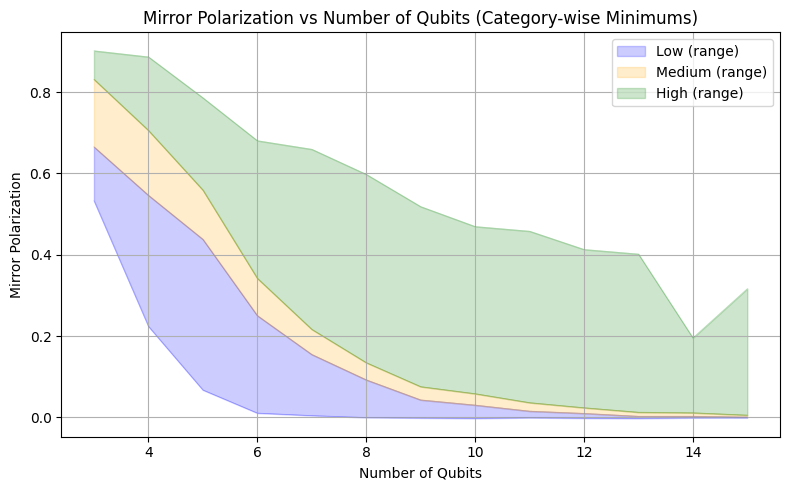

In [12]:
# check the polarization min values of polarization for each n_qubits group
n_qubits = list(range(3, 16))
low = full_dataset[full_dataset['polarization_category'] == 'low'].groupby('n_qubits')['polarization'].min().values
medium = full_dataset[full_dataset['polarization_category'] == 'medium'].groupby('n_qubits')['polarization'].min().values
high = full_dataset[full_dataset['polarization_category'] == 'high'].groupby('n_qubits')['polarization'].min().values
high_max = full_dataset[full_dataset['polarization_category'] == 'high'].groupby('n_qubits')['polarization'].max().values

# Create plot
plt.figure(figsize=(8, 5))

# Low category
plt.fill_between(n_qubits, low, medium, color='blue', alpha=0.2, label='Low (range)')
plt.plot(n_qubits, low, color='blue', linewidth=0.5, alpha=0.2)
plt.plot(n_qubits, medium, color='blue', linewidth=0.5, alpha=0.2)

# Medium category
plt.fill_between(n_qubits, medium, high, color='orange', alpha=0.2, label='Medium (range)')
plt.plot(n_qubits, medium, color='orange', linewidth=0.5, alpha=0.2)
plt.plot(n_qubits, high, color='orange', linewidth=0.5, alpha=0.2)

# High category
plt.fill_between(n_qubits, high, high_max, color='green', alpha=0.2, label='High (range)')
plt.plot(n_qubits, high, color='green', linewidth=0.5, alpha=0.2)
plt.plot(n_qubits, high_max, color='green', linewidth=0.5, alpha=0.2)

#plt.plot(n_qubits, low, marker='o', label='Low', linewidth=2)
#plt.plot(n_qubits, medium, marker='s', label='Medium', linewidth=2)
#plt.plot(n_qubits, high, marker='^', label='High', linewidth=2)

# Labels and styling
plt.xlabel("Number of Qubits")
plt.ylabel("Mirror Polarization")
plt.title("Mirror Polarization vs Number of Qubits (Category-wise Minimums)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# check the distribution of the new categories across different qubit counts
category_distribution = full_dataset.groupby(['n_qubits', 'polarization_category']).size().unstack(fill_value=0)
print("\nDistribution of polarization categories across different n_qubits:")
print(category_distribution)


Distribution of polarization categories across different n_qubits:
polarization_category  high  low  medium
n_qubits                                
3.0                       6    4       4
4.0                       9    9       9
5.0                      24   22      22
6.0                      58   56      56
7.0                      88   88      88
8.0                      91   89      89
9.0                      89   89      89
10.0                     93   93      93
11.0                     89   89      89
12.0                    106  105     105
13.0                     93   91      91
14.0                    103  103     103
15.0                     92   90      90


## EDA for normalized and non-normalized mirror polarization performance

In [14]:
from matplotlib import cm
#import IPython
cmap = cm.get_cmap("gnuplot")

C:\Users\KrystianBarłożewski\AppData\Local\Temp\ipykernel_6928\2741254065.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("gnuplot")


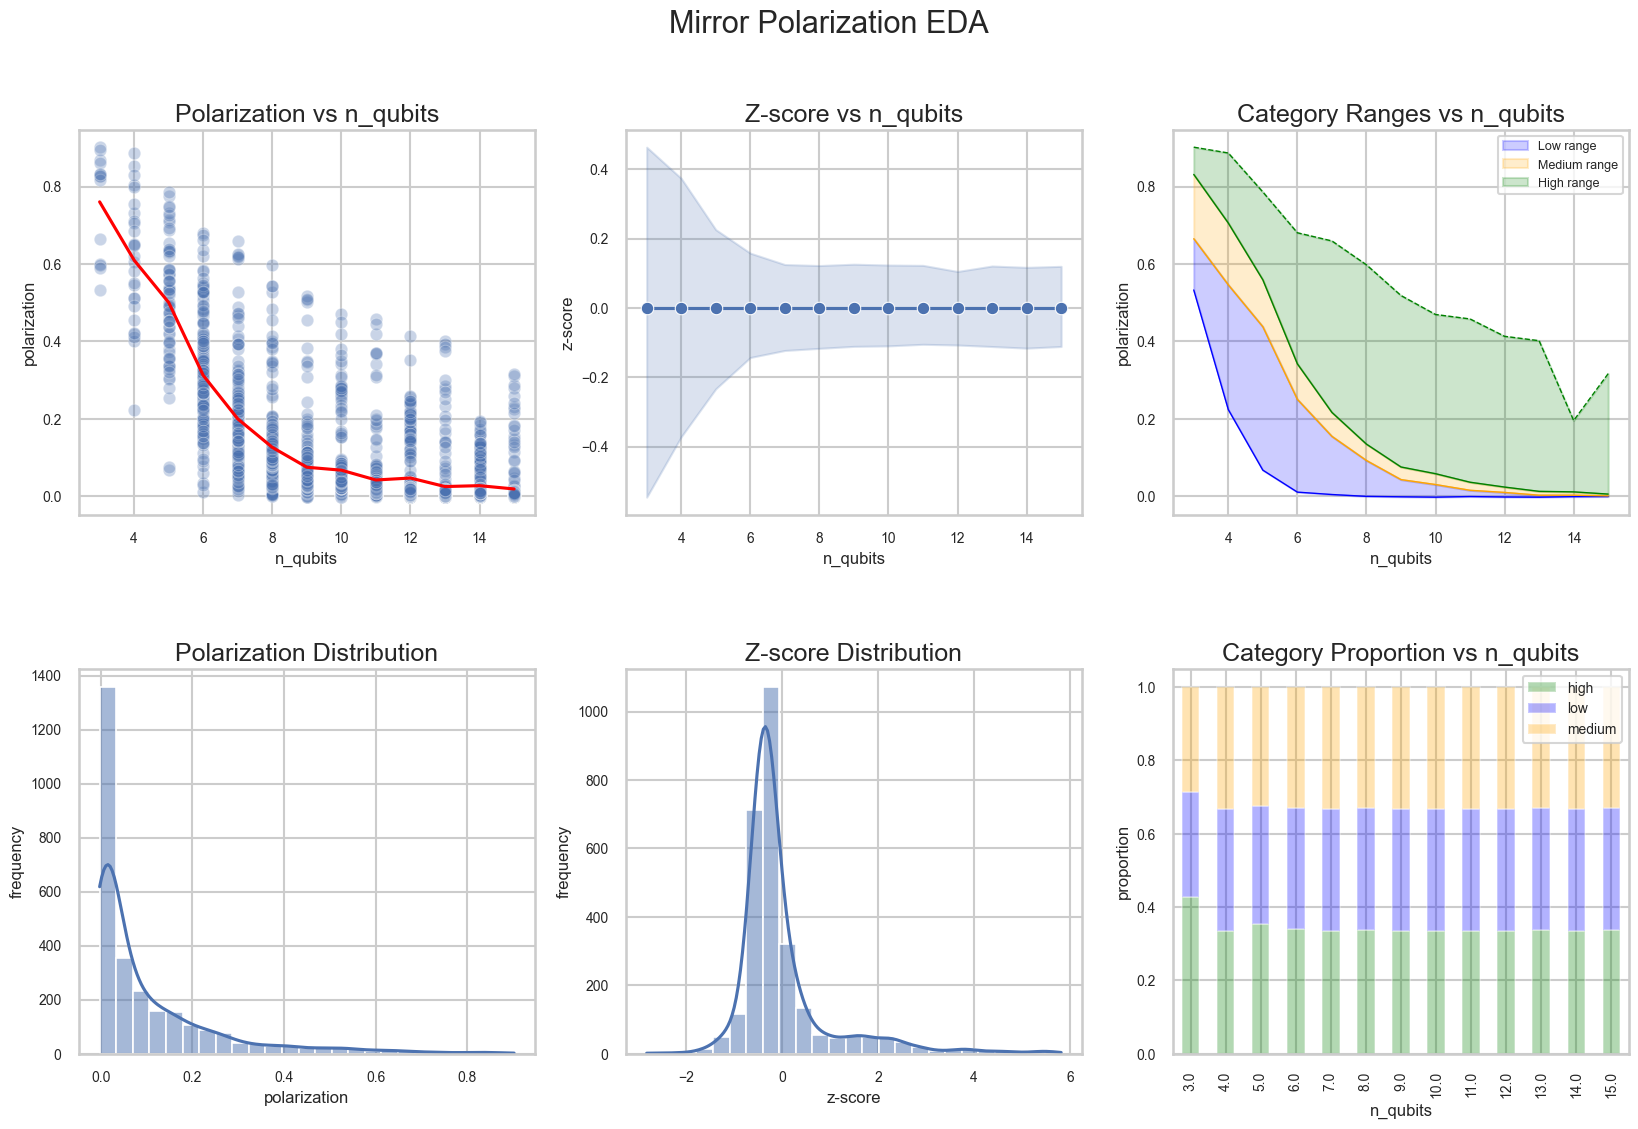

In [15]:
# Create a comprehensive EDA dashboard with multiple plots to analyze the polarization data in depth

sns.set(style="whitegrid", context="talk")
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# ---------------------------
# 1. Polarization vs n_qubits
# ---------------------------

sns.scatterplot(
    data=full_dataset,
    x='n_qubits',
    y='polarization',
    ax=axes[0, 0],
    alpha=0.3
)

sns.lineplot(
    data=full_dataset,
    x='n_qubits',
    y='polarization',
    ax=axes[0, 0],
    color='red',
    errorbar=None
)


axes[0, 0].set_title("Polarization vs n_qubits")
axes[0, 0].set_xlabel("n_qubits", fontsize=12)
axes[0, 0].set_ylabel("polarization", fontsize=12)

# ---------------------------
# 2. Z-score vs n_qubits
# ---------------------------
sns.lineplot(
    data=full_dataset,
    x='n_qubits',
    y='polarization_zscore',
    ax=axes[0, 1],
    marker='o'
)
axes[0, 1].set_title("Z-score vs n_qubits")
axes[0, 1].set_xlabel("n_qubits", fontsize=12)
axes[0, 1].set_ylabel("z-score", fontsize=12)

# ---------------------------
# 3. Category ranges
# ---------------------------
ax = axes[0, 2]

n_qubits = list(range(3, 16))

low = full_dataset[full_dataset['polarization_category'] == 'low'] \
    .groupby('n_qubits')['polarization'].min().reindex(n_qubits)

medium = full_dataset[full_dataset['polarization_category'] == 'medium'] \
    .groupby('n_qubits')['polarization'].min().reindex(n_qubits)

high = full_dataset[full_dataset['polarization_category'] == 'high'] \
    .groupby('n_qubits')['polarization'].min().reindex(n_qubits)

high_max = full_dataset[full_dataset['polarization_category'] == 'high'] \
    .groupby('n_qubits')['polarization'].max().reindex(n_qubits)

ax.fill_between(n_qubits, low, medium, color='blue', alpha=0.2, label='Low range')
ax.fill_between(n_qubits, medium, high, color='orange', alpha=0.2, label='Medium range')
ax.fill_between(n_qubits, high, high_max, color='green', alpha=0.2, label='High range')

ax.plot(n_qubits, low, color='blue', linewidth=1)
ax.plot(n_qubits, medium, color='orange', linewidth=1)
ax.plot(n_qubits, high, color='green', linewidth=1)
ax.plot(n_qubits, high_max, color='green', linestyle='--', linewidth=1)

ax.set_title("Category Ranges vs n_qubits")
ax.set_xlabel("n_qubits", fontsize=12)
ax.set_ylabel("polarization", fontsize=12)
ax.legend(fontsize=9)

# ---------------------------
# 4. Polarization distribution
# ---------------------------
sns.histplot(
    full_dataset['polarization'],
    bins=25,
    kde=True,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Polarization Distribution")
axes[1, 0].set_xlabel("polarization", fontsize=12)
axes[1, 0].set_ylabel("frequency", fontsize=12)


# ---------------------------
# 5. Z-score distribution
# ---------------------------
sns.histplot(
    full_dataset['polarization_zscore'],
    bins=25,
    kde=True,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Z-score Distribution")
axes[1, 1].set_xlabel("z-score", fontsize=12)
axes[1, 1].set_ylabel("frequency", fontsize=12)

# ---------------------------
# 6. Category counts
# ---------------------------

# Prepare color palette for categories
colors = {
    'low': 'blue',
    'medium': 'orange',
    'high': 'green'
}

# Prepare normalized data
counts = (
    full_dataset
    .groupby(['n_qubits', 'polarization_category'])
    .size()
    .unstack(fill_value=0)
)
counts = counts.div(counts.sum(axis=1), axis=0)

counts.plot(
    kind='bar',
    stacked=True,
    ax=axes[1, 2],
    # colormap='Set2',
    color=[colors[c] for c in counts.columns],
    alpha=0.3
)

axes[1, 2].set_title("Category Proportion vs n_qubits")
axes[1, 2].set_xlabel("n_qubits", fontsize=12)
axes[1, 2].set_ylabel("proportion", fontsize=12)
axes[1, 2].legend(fontsize=10)



# ---------------------------
# Layout improvements
# ---------------------------
plt.subplots_adjust(hspace=0.4)  # more vertical space between rows
for ax in axes.flat: # change font size of all axes labels
    ax.tick_params(axis='both', labelsize=10)

plt.suptitle("Mirror Polarization EDA", fontsize=22, y=0.98)
plt.show()

## TASK 1 - Feature performance and mirror polarization regression with Ridge and Lasso regression

In [16]:
scaler = MinMaxScaler()

# drop columns that are not features or targets
full_dataset_regression = full_dataset.drop(columns=['algo','n_qubits'], errors='ignore')

# list of features in full dataset excluding target and categorical columns
full_dataset["polarization_encoded"] = full_dataset["polarization_category"].map(mapping)
feature_columns = [col for col in full_dataset_regression.columns if col not in ['polarization', 
                                                                                 'polarization_category', 
                                                                                 'polarization_zscore', 
                                                                                 'polarization_zcategory', 
                                                                                 'polarization_encoded']]
print("Total number of features:", len(feature_columns))
for i in range(len(feature_columns)):
    print(i, ") ", feature_columns[i])

full_dataset_regression = full_dataset_regression[feature_columns + ['polarization', 'polarization_zscore']]
print("Shape of full dataset:", full_dataset_regression.shape)

#display(feature_columns)

#-----------------------------------------------------------------------------
# MODEL 1 - Ridge Regression 
#-----------------------------------------------------------------------------

# common parameters for all models
# create a list of alphas to test for Ridge regression
alphas = [0, 1.0, 2.0, 5.0,10.0, 20.0, 50.0, 100.0, 1000.0]  # regularization strengths for Ridge regression
random_state = 42  # for reproducibility

# Iterate over the list of alphas and train a Ridge regression model for each alpha, then evaluate its performance using R^2 score and print the results
r2_scores_ridge_polarization = []
r2_scores_ridge_zscore = []

for alpha in alphas:
    #--------------------------------------------------
    # Mirror Polarization as target variable
    #--------------------------------------------------

    # Prepapre the feature matrix X and target vector y
    X = full_dataset_regression[feature_columns]
    y = full_dataset_regression['polarization']  # Use the polarization as the target variable for Ridge regression

    # split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # scale the features using MinMaxScaler
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # train the Ridge regression model and evaluate its performance using R^2 score
    clf = Ridge(alpha=alpha, random_state=random_state).fit(X_train_scaled, y_train)
    r2_score = clf.score(X_test_scaled, y_test)
    r2_scores_ridge_polarization.append(r2_score)

    #print("\n##################################################################################\n")
    #print("Ridge Regression with Mirror Polarization as target variable")
    #print(f"Ridge Regression R^2 Score: {r2_score:.4f}")

    # Get feature importance from the Ridge regression model
    feature_importance_ridge = pd.Series(clf.coef_, index=feature_columns).sort_values(ascending=False)
    #print("\nNumber of features with non-zero coefficients:")
    #print(feature_importance_ridge[feature_importance_ridge != 0].shape[0])
    #print("\nTop 10 features by Ridge Regression importance:")
    #print(feature_importance_ridge.head(10))
    
    #--------------------------------------------------
    # Polarization_zscore as target variable
    #--------------------------------------------------
    y = full_dataset_regression['polarization_zscore']  # Use the z-score normalized polarization as the target variable for Ridge regression

    # split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # scale the features using MinMaxScaler
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # train the Ridge regression model and evaluate its performance using R^2 score
    clf = Ridge(alpha=alpha, random_state=random_state).fit(X_train_scaled, y_train)
    r2_score = clf.score(X_test_scaled, y_test)
    r2_scores_ridge_zscore.append(r2_score)

    #print("\n##################################################################################\n")
    #print("Ridge Regression with Z-score Normalized Polarization as Target")
    #print(f"Ridge Regression R^2 Score: {r2_score:.4f}")

    # Get feature importance from the Ridge regression model
    feature_importance_ridge = pd.Series(clf.coef_, index=feature_columns).sort_values(ascending=False)
    #print("\nNumber of features with non-zero coefficients:")
    # print(feature_importance_ridge[feature_importance_ridge != 0].shape[0])
    # print("\nTop 10 features by Ridge Regression importance:")
    # print(feature_importance_ridge.head(10))

# Create a summary of the R^2 scores for both target variables across different alpha values
r2_summary = pd.DataFrame({
    'Alpha': alphas,
    'Mirror Polarization': r2_scores_ridge_polarization,
    'Z-score Norm. Polarization': r2_scores_ridge_zscore
})

print("\nRidge Regression R^2 Scores for Different Alpha Values:\n")
print(r2_summary)

    ###########################################################################

Total number of features: 41
0 )  depth
1 )  size
2 )  num_2q_gates
3 )  program_communication
4 )  critical_depth
5 )  entanglement_ratio
6 )  parallelism
7 )  liveness
8 )  fiedler_topology
9 )  spectral_entropy_topology
10 )  laplacian_max_eig_topology
11 )  spectral_gap_ratio_topology
12 )  effective_resistance
13 )  log_spanning_trees
14 )  laplacian_energy
15 )  von_neumann_entropy
16 )  fiedler_2q_weighted
17 )  spectral_entropy_2q_weighted
18 )  gini_2q_multiplicity
19 )  edge_weight_mean_2q
20 )  log_estrada_index
21 )  graph_density
22 )  graph_diameter
23 )  avg_clustering
24 )  max_degree
25 )  degree_variance
26 )  assortativity
27 )  num_triangles
28 )  twoq_temporal_locality
29 )  gate_entropy
30 )  num_unique_gates
31 )  depth_per_qubit
32 )  fiedler_at_half_depth
33 )  time_to_connected
34 )  has_2q_interactions
35 )  n_rotation_gates
36 )  mean_abs_angle
37 )  std_angle
38 )  sum_sin_sq_half
39 )  mean_angle_squared
40 )  angle_position_weighted
Shape of full dataset:

### Lasso regression

In [17]:
# Define the dataset for Lasso regression
targets = ['polarization', 'polarization_zscore']
lasso_dataset = full_dataset_regression[feature_columns + targets]  
X = lasso_dataset[feature_columns]

# Create a list of alphas to test for Lasso regression
alphas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.05, 0.1]  # regularization strengths for Lasso regression
random_state = 42  # for reproducibility

# Iterate over the list of alphas and train a Lasso regression model for each alpha, then evaluate its performance using R^2 score and print the results
r2_scores_lasso_polarization = []
r2_scores_lasso_zscore = []

# Create scaler for MinMax normalization in Lasso regression
scaler = MinMaxScaler()


for target in targets:
    y = lasso_dataset[target]  # Use the polarization as the target variable for Lasso regression

    # split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # scale the features using MinMaxScaler
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Reset the r2_score
    r2_score_polarization_max = 0  
    r2_score_zscore_max = 0

    for alpha in alphas:
        # train the Lasso regression model and evaluate its performance using R^2 score
        linlasso = Lasso(alpha=alpha, random_state=random_state, max_iter=10000).fit(X_train_scaled, y_train)
        r2_score = linlasso.score(X_test_scaled, y_test)
        #print(f"\nLasso Regression with {target} as target variable and alpha={alpha}: R^2 = {r2_score:.4f}")

        if target == 'polarization':
            r2_scores_lasso_polarization.append(r2_score)
            if r2_score > r2_score_polarization_max:
                feature_importance_lasso_polarization = pd.Series(linlasso.coef_, index=feature_columns).sort_values(key=abs, ascending=False)
        else:
            r2_scores_lasso_zscore.append(r2_score)
            if r2_score > r2_score_zscore_max:
                feature_importance_lasso_zscore = pd.Series(linlasso.coef_, index=feature_columns).sort_values(key=abs, ascending=False)

        # Get feature importance from the Lasso regression model
        

# Summarize the R^2 scores for Lasso regression across different alpha values and target variables
r2_summary_lasso = pd.DataFrame({
    'Alpha': alphas,
    'R2_Score_Polarization': r2_scores_lasso_polarization,
    'R2_Score_ZScore': r2_scores_lasso_zscore
})

print("\nLasso Regression R^2 Scores for Different Alpha Values:\n")
print(r2_summary_lasso)
print("Features with non-zero weight for mirror polarization as target: )")
print(feature_importance_lasso_polarization[:5])
print("Features with non-zero weight for zscore as target: )")
print(feature_importance_lasso_zscore[:5])




Lasso Regression R^2 Scores for Different Alpha Values:

      Alpha  R2_Score_Polarization  R2_Score_ZScore
0  0.000001               0.895684         0.713594
1  0.000010               0.903688         0.714599
2  0.000100               0.906049         0.718533
3  0.001000               0.806556         0.703074
4  0.010000               0.433153         0.566306
5  0.050000              -0.000407         0.396674
6  0.100000              -0.000407         0.070443
Features with non-zero weight for mirror polarization as target: )
spectral_entropy_topology   -0.164099
von_neumann_entropy         -0.090574
depth                       -0.086733
size                        -0.000000
num_2q_gates                -0.000000
dtype: float64
Features with non-zero weight for zscore as target: )
twoq_temporal_locality   -0.214837
time_to_connected         0.199351
num_2q_gates              0.000000
size                      0.000000
critical_depth            0.000000
dtype: float64
